# Churn Labeling - Non-Contractual Setting

Phương pháp:
1. Tính IPT (Inter-Purchase Time) cho từng user
2. Tính Lapse Point = μ + 2σ của IPT
3. Gán nhãn Churn = 1 nếu Recency trong Target Window > Lapse Point

**Không data leakage**: nhãn chỉ dựa trên hành vi trong Target Window, không dùng thông tin từ Feature Window để gán nhãn.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r'c:\Users\Admin\data_driven_marketing'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')

df = pd.read_pickle(os.path.join(DATA_DIR, 'df_full.pkl'))

# Chuẩn hóa cột thời gian
if 'visitStartTime_datetime' in df.columns:
    df['event_date'] = pd.to_datetime(df['visitStartTime_datetime'], errors='coerce')
elif 'date' in df.columns:
    df['event_date'] = pd.to_datetime(df['date'], errors='coerce')
else:
    df['event_date'] = pd.to_datetime(df['visitStartTime'], unit='s', errors='coerce')

df['fullVisitorId'] = df['fullVisitorId'].astype(str)

print('Shape:', df.shape)
print('Date range:', df['event_date'].min(), '->', df['event_date'].max())

Shape: (1708337, 60)
Date range: 2016-08-01 07:00:12 -> 2018-05-01 06:56:58


In [3]:
# ==============================================================
# BƯỚC 1: Tính IPT (Inter-Purchase Time)
# Chỉ tính trên toàn bộ lịch sử, KHÔNG dùng feature/target window
# Mục đích: xác định ngưỡng churn toàn cục
# ==============================================================

# Lấy 1 session/ngày mỗi user (unique visit per day)
visits = (
    df[['fullVisitorId', 'event_date']]
    .drop_duplicates()
    .sort_values(['fullVisitorId', 'event_date'])
    .copy()
)

# Tính khoảng cách giữa các lần visit liên tiếp
visits['prev_date'] = visits.groupby('fullVisitorId')['event_date'].shift(1)
visits['ipt_days'] = (visits['event_date'] - visits['prev_date']).dt.days

# Chỉ giữ các user có >= 2 lần visit mới tính được IPT
ipt_series = visits['ipt_days'].dropna()

mu = ipt_series.mean()
sigma = ipt_series.std()
lapse_point = mu + 2 * sigma

print('='*60)
print('IPT Statistics (toàn bộ lịch sử):')
print(f'  Số cặp visit có IPT: {len(ipt_series):,}')
print(f'  Mean IPT (μ):        {mu:.2f} ngày')
print(f'  Std IPT (σ):         {sigma:.2f} ngày')
print(f'  Lapse Point (μ+2σ):  {lapse_point:.2f} ngày')
print('='*60)
print()
print(f'Ý nghĩa: Nếu khách không quay lại sau {lapse_point:.0f} ngày,')
print('         xác suất họ đã churn > 95%.')

IPT Statistics (toàn bộ lịch sử):
  Số cặp visit có IPT: 384,607
  Mean IPT (μ):        10.89 ngày
  Std IPT (σ):         31.94 ngày
  Lapse Point (μ+2σ):  74.77 ngày

Ý nghĩa: Nếu khách không quay lại sau 75 ngày,
         xác suất họ đã churn > 95%.


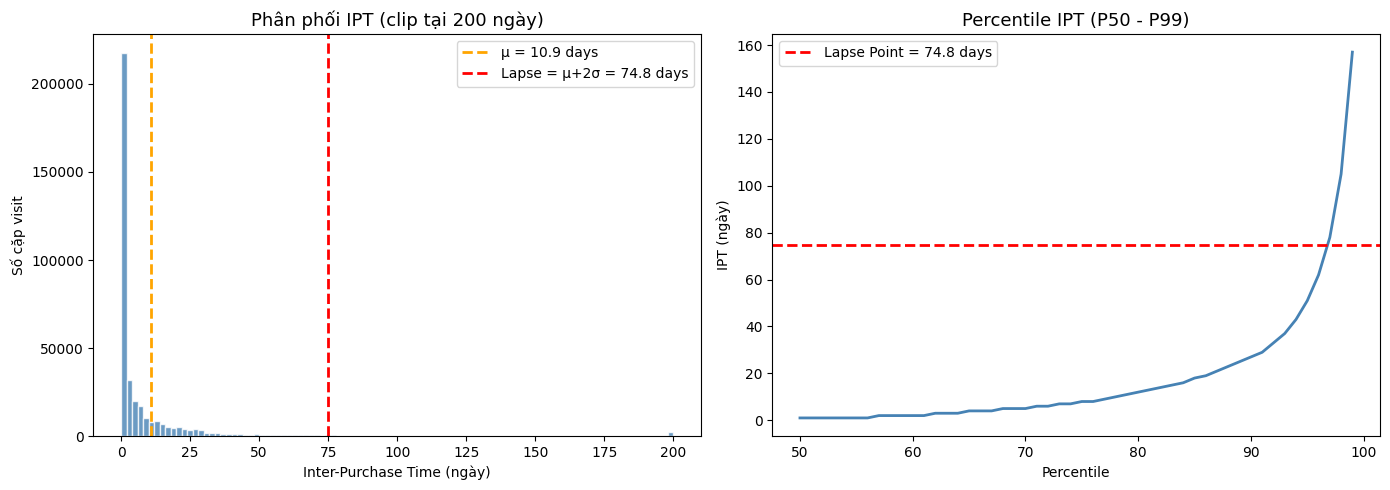

In [3]:
# Visualize phân phối IPT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(ipt_series.clip(upper=200), bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(mu, color='orange', linestyle='--', linewidth=2, label=f'μ = {mu:.1f} days')
axes[0].axvline(lapse_point, color='red', linestyle='--', linewidth=2, label=f'Lapse = μ+2σ = {lapse_point:.1f} days')
axes[0].set_title('Phân phối IPT (clip tại 200 ngày)', fontsize=13)
axes[0].set_xlabel('Inter-Purchase Time (ngày)')
axes[0].set_ylabel('Số cặp visit')
axes[0].legend()

# Percentile view
pcts = np.arange(50, 100, 1)
vals = np.percentile(ipt_series, pcts)
axes[1].plot(pcts, vals, color='steelblue', linewidth=2)
axes[1].axhline(lapse_point, color='red', linestyle='--', linewidth=2, label=f'Lapse Point = {lapse_point:.1f} days')
axes[1].set_title('Percentile IPT (P50 - P99)', fontsize=13)
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('IPT (ngày)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# ==============================================================
# BƯỚC 2: Hàm gán nhãn Churn cho từng fold
#
# Logic KHÔNG data leakage:
#   - Feature Window: [feature_start, feature_end)  -> tính features
#   - Target Window : [target_start, target_end)    -> tính nhãn
#
# Churn = 1 nếu:
#   Recency = (target_end - last_visit_in_target_window) > lapse_point
#   HOẶC user hoàn toàn không xuất hiện trong Target Window
# ==============================================================

def label_churn_for_fold(df_raw, k, feature_days, target_days,
                          step_days, lapse_point_days, base_date):
    """
    Trả về DataFrame mức user với cột:
      - fullVisitorId
      - fold_id
      - feature_start, feature_end, target_start, target_end
      - last_visit_in_feature   : ngày visit cuối trong Feature Window
      - recency_past            : (feature_end - last_visit_in_feature)
      - is_churn_past           : recency_past > lapse_point_days
      - last_visit_in_target    : ngày visit cuối trong Target Window (NaT nếu không xuất hiện)
      - appeared_in_target      : 1/0 - có xuất hiện trong Target Window
      - recency_days            : số ngày kể từ last visit in target đến target_end
      - churn                   : NHÃN (1 = churn, 0 = active)
    """
    feature_start = base_date + pd.Timedelta(days=step_days * (k - 1))
    feature_end   = feature_start + pd.Timedelta(days=feature_days)
    target_start  = feature_end
    target_end    = target_start + pd.Timedelta(days=target_days)

    if target_end > df_raw['event_date'].max():
        print(f'Skip Fold {k}: target_end {target_end.date()} > max_date {df_raw["event_date"].max().date()}')
        return None

    # Users xuất hiện trong Feature Window
    df_feat = df_raw[
        (df_raw['event_date'] >= feature_start) &
        (df_raw['event_date'] <  feature_end)
    ]
    users_in_feature = df_feat['fullVisitorId'].unique()

    # Last visit của mỗi user trong Feature Window
    last_feat = (
        df_feat.groupby('fullVisitorId')['event_date']
        .max()
        .rename('last_visit_in_feature')
        .reset_index()
    )

    # -----------------------------------------------------------
    # TARGET WINDOW: chỉ dùng để gán nhãn, KHÔNG leak vào features
    # -----------------------------------------------------------
    df_tgt = df_raw[
        (df_raw['event_date'] >= target_start) &
        (df_raw['event_date'] <  target_end)
    ]

    # Chỉ xét users đã xuất hiện trong Feature Window
    df_tgt_feat_users = df_tgt[df_tgt['fullVisitorId'].isin(users_in_feature)]

    # Last visit của mỗi user trong Target Window
    last_tgt = (
        df_tgt_feat_users.groupby('fullVisitorId')['event_date']
        .max()
        .rename('last_visit_in_target')
        .reset_index()
    )

    # Merge
    fold_df = last_feat.merge(last_tgt, on='fullVisitorId', how='left')

    # --- 1. TÍNH BIẾN QUÁ KHỨ (FEATURES) ---
    fold_df['recency_past'] = (feature_end - fold_df['last_visit_in_feature']).dt.days
    fold_df['is_churn_past'] = (fold_df['recency_past'] > lapse_point_days).astype(int)

    # --- 2. TÍNH NHÃN TƯƠNG LAI (TARGET) ---
    fold_df['appeared_in_target'] = fold_df['last_visit_in_target'].notna().astype(int)

    # Recency = target_end - last_visit_in_target
    fold_df['last_visit_for_recency'] = fold_df['last_visit_in_target'].fillna(target_start)
    fold_df['recency_days'] = (target_end - fold_df['last_visit_for_recency']).dt.days

    # NHÃN CHURN THẬT
    fold_df['churn'] = (fold_df['recency_days'] > lapse_point_days).astype(int)

    # Metadata
    fold_df['fold_id']       = k
    fold_df['feature_start'] = feature_start
    fold_df['feature_end']   = feature_end
    fold_df['target_start']  = target_start
    fold_df['target_end']    = target_end

    n_users  = len(fold_df)
    n_churn  = fold_df['churn'].sum()
    n_active = n_users - n_churn
    print(f'Fold {k}: Feature {feature_start.date()} -> {feature_end.date()} | '
          f'Target {target_start.date()} -> {target_end.date()} | '
          f'Users={n_users:,} | Churn={n_churn:,} ({n_churn/n_users*100:.1f}%) | '
          f'Active={n_active:,} ({n_active/n_users*100:.1f}%)')

    return fold_df[[
        'fullVisitorId', 'fold_id',
        'feature_start', 'feature_end', 'target_start', 'target_end',
        'last_visit_in_feature', 'recency_past', 'is_churn_past',
        'last_visit_in_target', 'appeared_in_target', 'recency_days', 'churn'
    ]]


print('Hàm label_churn_for_fold đã sẵn sàng.')

Hàm label_churn_for_fold đã sẵn sàng.


In [5]:
# ==============================================================
# BƯỚC 3: Thiết lập Time Windows (giống Train_test_split.ipynb)
# ==============================================================

FEATURE_DAYS = 168
TARGET_DAYS  = 92
STEP_DAYS    = 60

base_date = df['event_date'].min()
max_date  = df['event_date'].max()

print(f'Base date : {base_date.date()}')
print(f'Max date  : {max_date.date()}')
print(f'Lapse Point: {lapse_point:.2f} ngày')

Base date : 2016-08-01
Max date  : 2018-05-01
Lapse Point: 74.77 ngày


In [8]:
# ==============================================================
# BƯỚC 4: Chạy gán nhãn cho tất cả các fold
# ==============================================================

print(f'Lapse Point = {lapse_point:.2f} ngày\n')
print('='*90)

fold_labels = []
k = 1
while True:
    result = label_churn_for_fold(
        df_raw           = df,
        k                = k,
        feature_days     = FEATURE_DAYS,
        target_days      = TARGET_DAYS,
        step_days        = STEP_DAYS,
        lapse_point_days = lapse_point,
        base_date        = base_date
    )
    if result is None:
        break
    fold_labels.append(result)
    k += 1

print('='*90)
all_labels = pd.concat(fold_labels, ignore_index=True)
print(f'\nTổng số fold: {all_labels["fold_id"].nunique()}')
print(f'Tổng số records: {len(all_labels):,}')
print(f'Churn rate tổng: {all_labels["churn"].mean()*100:.2f}%')

Lapse Point = 74.77 ngày

Fold 1: Feature 2016-08-01 -> 2017-01-16 | Users=377,131 | Churn Rate=99.2%
Fold 2: Feature 2016-09-30 -> 2017-03-17 | Users=369,021 | Churn Rate=99.1%
Fold 3: Feature 2016-11-29 -> 2017-05-16 | Users=300,714 | Churn Rate=99.0%
Fold 4: Feature 2017-01-28 -> 2017-07-15 | Users=290,530 | Churn Rate=98.8%
Fold 5: Feature 2017-03-29 -> 2017-09-13 | Users=305,377 | Churn Rate=98.8%
Fold 6: Feature 2017-05-28 -> 2017-11-12 | Users=350,589 | Churn Rate=98.8%
Fold 7: Feature 2017-07-27 -> 2018-01-11 | Users=387,659 | Churn Rate=98.8%
Skip Fold 8: target_end 2018-06-12 > max_date 2018-05-01

Tổng số fold: 7
Tổng số records: 2,381,021
Churn rate tổng: 98.94%


In [9]:
# ==============================================================
# BƯỚC 5: Kiểm tra phân bố nhãn theo fold
# ==============================================================

summary = (
    all_labels.groupby('fold_id')
    .agg(
        n_users          = ('fullVisitorId', 'count'),
        n_churn          = ('churn', 'sum'),
        churn_rate       = ('churn', 'mean'),
        appeared_in_tgt  = ('appeared_in_target', 'mean'),
        mean_recency     = ('recency_days', 'mean'),
        feature_start    = ('feature_start', 'first'),
        target_end       = ('target_end', 'first')
    )
    .reset_index()
)

summary['churn_rate_pct']      = (summary['churn_rate'] * 100).round(2)
summary['appeared_in_tgt_pct'] = (summary['appeared_in_tgt'] * 100).round(2)
summary['mean_recency']        = summary['mean_recency'].round(1)

display(summary[[
    'fold_id', 'n_users', 'n_churn', 'churn_rate_pct',
    'appeared_in_tgt_pct', 'mean_recency',
    'feature_start', 'target_end'
]])

,fold_id,n_users,n_churn,churn_rate_pct,appeared_in_tgt_pct,mean_recency,feature_start,target_end
0,1,377131,374174,99.22,1.26,91.6,2016-08-01 07:00:12,2017-04-18 07:00:12
1,2,369021,365822,99.13,1.31,91.5,2016-09-30 07:00:12,2017-06-17 07:00:12
2,3,300714,297668,98.99,1.62,91.4,2016-11-29 07:00:12,2017-08-16 07:00:12
3,4,290530,287144,98.83,1.80,91.4,2017-01-28 07:00:12,2017-10-15 07:00:12
4,5,305377,301588,98.76,1.95,91.3,2017-03-29 07:00:12,2017-12-14 07:00:12
5,6,350589,346207,98.75,2.01,91.3,2017-05-28 07:00:12,2018-02-12 07:00:12
6,7,387659,383098,98.82,1.70,91.3,2017-07-27 07:00:12,2018-04-13 07:00:12


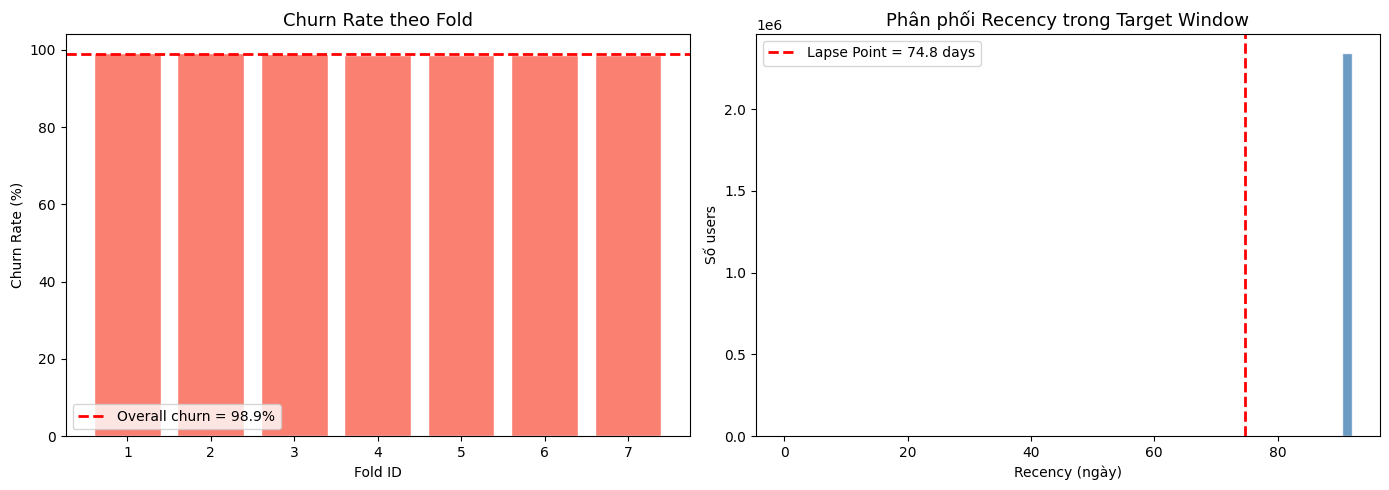

In [10]:
# ==============================================================
# BƯỚC 6: Visualize churn rate & recency distribution
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary['fold_id'], summary['churn_rate_pct'], color='salmon', edgecolor='white')
axes[0].axhline(all_labels['churn'].mean()*100, color='red', linestyle='--',
                linewidth=2, label=f'Overall churn = {all_labels["churn"].mean()*100:.1f}%')
axes[0].set_title('Churn Rate theo Fold', fontsize=13)
axes[0].set_xlabel('Fold ID')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend()

axes[1].hist(all_labels['recency_days'].clip(upper=TARGET_DAYS+5), bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(lapse_point, color='red', linestyle='--', linewidth=2,
                label=f'Lapse Point = {lapse_point:.1f} days')
axes[1].set_title('Phân phối Recency trong Target Window', fontsize=13)
axes[1].set_xlabel('Recency (ngày)')
axes[1].set_ylabel('Số users')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# ==============================================================
# BƯỚC 7: Lưu kết quả
# ==============================================================

out_path = os.path.join(DATA_DIR, 'churn_labels.pkl')
all_labels.to_pickle(out_path)
print(f'Đã lưu: {out_path}')
print(f'Shape: {all_labels.shape}')
print()
print('Columns:')
print(all_labels.dtypes)
print()
print('Sample:')
display(all_labels.head(10))

Đã lưu: c:\Users\Admin\data_driven_marketing\data\churn_labels.pkl
Shape: (2381021, 13)

Columns:
fullVisitorId                       str
fold_id                           int64
feature_start            datetime64[ns]
feature_end              datetime64[ns]
target_start             datetime64[ns]
target_end               datetime64[ns]
last_visit_in_feature    datetime64[ns]
recency_past                      int64
is_churn_past                     int64
last_visit_in_target     datetime64[ns]
appeared_in_target                int64
recency_days                      int64
churn                             int64
dtype: object

Sample:


,fullVisitorId,fold_id,feature_start,feature_end,target_start,target_end,last_visit_in_feature,recency_past,is_churn_past,last_visit_in_target,appeared_in_target,recency_days,churn
0,0000010278554503158,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-10-21 05:57:46,87,1,NaT,0,92,1
1,0000020424342248747,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-12-01 07:55:01,45,0,NaT,0,92,1
2,000005103959234087,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-08-21 22:06:48,147,1,NaT,0,92,1
3,0000093957001069502,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-09-27 14:15:24,110,1,NaT,0,92,1
4,0000114156543135683,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-08-08 10:47:20,160,1,NaT,0,92,1
5,0000152474579038632,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-10-23 08:28:26,84,1,NaT,0,92,1
6,0000168159078983594,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-09-25 02:15:18,113,1,NaT,0,92,1
7,0000174067426171406,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-11-12 05:05:57,65,0,NaT,0,92,1
8,0000245437374675368,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-09-03 00:34:02,135,1,NaT,0,92,1
9,0000253133284033056,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-08-09 15:17:26,159,1,NaT,0,92,1


In [4]:
# Gán Churn tổng bằng cách groupby fullVisitorId
max_date_global = df['event_date'].max()

df_churn = (
    df.groupby('fullVisitorId')['event_date']
    .max()
    .reset_index()
    .rename(columns={'event_date': 'last_visit_date'})
)

# Tính số ngày kể từ lần truy cập cuối đến thời điểm cuối cùng của dữ liệu
df_churn['recency_total'] = (max_date_global - df_churn['last_visit_date']).dt.days

# Gán nhãn churn: 1 nếu recency > lapse_point, ngược lại là 0
df_churn['is_churn_total'] = (df_churn['recency_total'] > lapse_point).astype(int)

# Kiểm tra kết quả
print(f"Tổng số khách hàng: {len(df_churn):,}")
print(f"Tỷ lệ Churn tổng: {df_churn['is_churn_total'].mean()*100:.2f}%")

# Lưu nếu cần (tùy chọn)
df_churn.to_pickle(os.path.join(DATA_DIR, 'df_churn.pkl'))

Tổng số khách hàng: 1,323,730
Tỷ lệ Churn tổng: 87.00%


In [5]:
df_churn.head(10)

,fullVisitorId,last_visit_date,recency_total,is_churn_total
0,0000000259678714014,2017-11-29 00:19:40,153,1
1,0000010278554503158,2016-10-21 05:57:46,557,1
2,0000020424342248747,2016-12-01 07:55:01,515,1
3,0000027376579751715,2017-02-12 02:24:53,443,1
4,0000039460501403861,2017-03-27 15:45:16,399,1
5,0000040862739425590,2017-02-11 18:47:04,443,1
6,0000049363351866189,2017-09-19 23:31:14,223,1
7,000005103959234087,2016-08-21 22:06:48,617,1
8,0000053049821714864,2018-01-28 22:32:22,92,1
9,0000059488412965267,2018-02-28 03:14:59,62,0
